# csv to raw dataset

### pandas to parse the csv on drive to sql

In [ ]:
import duckdb 
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
import pandas as pd

path = 'data/raw/who-household-air-pollution.csv'
df = pd.read_csv(path, delimiter=",")


In [3]:
print(df.shape)

(13752, 34)


In [4]:
df.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,...,FactValueUoM,FactValueNumericLowPrefix,FactValueNumericLow,FactValueNumericHighPrefix,FactValueNumericHigh,Value,FactValueTranslationID,FactComments,Language,DateModified
0,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,GNB,Guinea-Bissau,Year,2023,...,NaN,NaN,0.0,NaN,3.2,0.0 [0.0-3.2],NaN,NaN,EN,2025-05-02T05:00:00.000Z
1,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,LBR,Liberia,Year,2023,...,NaN,NaN,0.0,NaN,3.4,0.0 [0.0-3.4],NaN,NaN,EN,2025-05-02T05:00:00.000Z
2,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,SLE,Sierra Leone,Year,2023,...,NaN,NaN,0.0,NaN,4.1,0.0 [0.0-4.1],NaN,NaN,EN,2025-05-02T05:00:00.000Z
3,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,SSD,South Sudan,Year,2023,...,NaN,NaN,0.0,NaN,5.2,0.0 [0.0-5.2],NaN,NaN,EN,2025-05-02T05:00:00.000Z
4,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,SSD,South Sudan,Year,2023,...,NaN,NaN,0.0,NaN,5.4,0.0 [0.0-5.4],NaN,NaN,EN,2025-05-02T05:00:00.000Z


### to sql

In [5]:
!pip install duckdb

In [ ]:
import duckdb

con = duckdb.connect('db/household_air_pollution.db')

con.execute("""
CREATE TABLE household_air_pollution_raw AS

SELECT
    CAST(IndicatorCode AS VARCHAR)                AS indicator_code,
    CAST(Indicator AS VARCHAR)                    AS indicator_name,
    CAST(ValueType AS VARCHAR)                    AS value_type,

    CAST(ParentLocationCode AS VARCHAR)           AS parent_location_code,
    CAST(ParentLocation AS VARCHAR)               AS parent_location_name,
    CAST("Location type" AS VARCHAR)              AS location_type,

    CAST(SpatialDimValueCode AS VARCHAR)          AS country_code,
    CAST(Location AS VARCHAR)                     AS country_name,

    CAST("Period type" AS VARCHAR)                AS period_type,
    CAST(Period AS INTEGER)                       AS year,
    CAST(IsLatestYear AS BOOLEAN)                 AS is_latest_year,

    CAST("Dim1 type" AS VARCHAR)                  AS dim1_type,
    CAST(Dim1 AS VARCHAR)                         AS dim1,
    CAST(Dim1ValueCode AS VARCHAR)                AS dim1_value_code,

    CAST("Dim2 type" AS VARCHAR)                  AS dim2_type,
    CAST(Dim2 AS VARCHAR)                         AS dim2,
    CAST(Dim2ValueCode AS VARCHAR)                AS dim2_value_code,

    CAST("Dim3 type" AS VARCHAR)                  AS dim3_type,
    CAST(Dim3 AS VARCHAR)                         AS dim3,
    CAST(Dim3ValueCode AS VARCHAR)                AS dim3_value_code,

    CAST(DataSourceDimValueCode AS VARCHAR)       AS data_source_dim_value_code,
    CAST(DataSource AS VARCHAR)                   AS data_source,

    CAST(FactValueNumericPrefix AS VARCHAR)       AS fact_value_numeric_prefix,
    CAST(FactValueNumeric AS DOUBLE)              AS value,
    CAST(FactValueUoM AS VARCHAR)                 AS unit,

    CAST(FactValueNumericLowPrefix AS VARCHAR)    AS lower_prefix,
    CAST(FactValueNumericLow AS DOUBLE)           AS lower_bound,
    CAST(FactValueNumericHighPrefix AS VARCHAR)   AS upper_prefix,
    CAST(FactValueNumericHigh AS DOUBLE)          AS upper_bound,

    CAST(Value AS VARCHAR)                        AS value_display,
    CAST(FactValueTranslationID AS VARCHAR)       AS translation_id,
    CAST(FactComments AS VARCHAR)                 AS fact_comments,
    CAST(Language AS VARCHAR)                     AS language,
    CAST(DateModified AS TIMESTAMP)               AS date_modified

FROM read_csv_auto('data/raw/who-household-air-pollution.csv')
""")

In [7]:
con.execute("""
SELECT *
FROM household_air_pollution_raw
LIMIT 5
""").fetchdf()

,indicator_code,indicator_name,value_type,parent_location_code,parent_location_name,location_type,country_code,country_name,period_type,year,...,unit,lower_prefix,lower_bound,upper_prefix,upper_bound,value_display,translation_id,fact_comments,language,date_modified
0,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,GNB,Guinea-Bissau,Year,2023,...,None,None,0.0,None,3.2,0.0 [0.0-3.2],None,None,EN,2025-05-02 05:00:00
1,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,LBR,Liberia,Year,2023,...,None,None,0.0,None,3.4,0.0 [0.0-3.4],None,None,EN,2025-05-02 05:00:00
2,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,SLE,Sierra Leone,Year,2023,...,None,None,0.0,None,4.1,0.0 [0.0-4.1],None,None,EN,2025-05-02 05:00:00
3,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,SSD,South Sudan,Year,2023,...,None,None,0.0,None,5.2,0.0 [0.0-5.2],None,None,EN,2025-05-02 05:00:00
4,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,SSD,South Sudan,Year,2023,...,None,None,0.0,None,5.4,0.0 [0.0-5.4],None,None,EN,2025-05-02 05:00:00


# analysis on raw dataset

## importing raw dataset

In [8]:
df2 = con.execute("""
SELECT *
FROM household_air_pollution_raw
""").fetchdf()

In [9]:
df2.shape

(13752, 34)

## dataset eda

In [10]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13752 entries, 0 to 13751
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   indicator_code              13752 non-null  object        
 1   indicator_name              13752 non-null  object        
 2   value_type                  13752 non-null  object        
 3   parent_location_code        13752 non-null  object        
 4   parent_location_name        13752 non-null  object        
 5   location_type               13752 non-null  object        
 6   country_code                13752 non-null  object        
 7   country_name                13752 non-null  object        
 8   period_type                 13752 non-null  object        
 9   year                        13752 non-null  int32         
 10  is_latest_year              13752 non-null  bool          
 11  dim1_type                   13752 non-null  object    

### missing values

 missing values to handle:
  * delete null rows

In [12]:

df2 = df2.dropna(axis=1, how="all")
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13752 entries, 0 to 13751
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   indicator_code        13752 non-null  object        
 1   indicator_name        13752 non-null  object        
 2   value_type            13752 non-null  object        
 3   parent_location_code  13752 non-null  object        
 4   parent_location_name  13752 non-null  object        
 5   location_type         13752 non-null  object        
 6   country_code          13752 non-null  object        
 7   country_name          13752 non-null  object        
 8   period_type           13752 non-null  object        
 9   year                  13752 non-null  int32         
 10  is_latest_year        13752 non-null  bool          
 11  dim1_type             13752 non-null  object        
 12  dim1                  13752 non-null  object        
 13  dim1_value_code 

In [13]:
df2.head()

,indicator_code,indicator_name,value_type,parent_location_code,parent_location_name,location_type,country_code,country_name,period_type,year,is_latest_year,dim1_type,dim1,dim1_value_code,value,lower_bound,upper_bound,value_display,language,date_modified
0,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,GNB,Guinea-Bissau,Year,2023,True,Residence Area Type,Rural,RESIDENCEAREATYPE_RUR,0.0,0.0,3.2,0.0 [0.0-3.2],EN,2025-05-02 05:00:00
1,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,LBR,Liberia,Year,2023,True,Residence Area Type,Rural,RESIDENCEAREATYPE_RUR,0.0,0.0,3.4,0.0 [0.0-3.4],EN,2025-05-02 05:00:00
2,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,SLE,Sierra Leone,Year,2023,True,Residence Area Type,Rural,RESIDENCEAREATYPE_RUR,0.0,0.0,4.1,0.0 [0.0-4.1],EN,2025-05-02 05:00:00
3,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,SSD,South Sudan,Year,2023,True,Residence Area Type,Rural,RESIDENCEAREATYPE_RUR,0.0,0.0,5.2,0.0 [0.0-5.2],EN,2025-05-02 05:00:00
4,PHE_HHAIR_PROP_POP_CLEAN_FUELS,Proportion of population with primary reliance...,text,AFR,Africa,Country,SSD,South Sudan,Year,2023,True,Residence Area Type,Total,RESIDENCEAREATYPE_TOTL,0.0,0.0,5.4,0.0 [0.0-5.4],EN,2025-05-02 05:00:00


### cleaning/ensuring remaining data is suitable

In [25]:
# country count just for ease of comparison
df2['country_name'].nunique()

191

In [36]:
df2['location_type'].nunique()

1

#### years

In [22]:
df2['year'].unique()

array([2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013,
       2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002,
       2001, 2000], dtype=int32)

In [33]:
df2[df2['is_latest_year'] == True]['country_name'].nunique()

191

#### zones

In [34]:
df2['dim1'].unique()

array(['Rural', 'Total', 'Urban'], dtype=object)

## transformed dataset

### base, clean table

In [37]:
con.execute("""
CREATE OR REPLACE TABLE household_air_pollution_clean AS
SELECT
    indicator_code,
    indicator_name,
    parent_location_code      AS region_code,
    parent_location_name      AS region_name,
    country_code,
    country_name,
    year,
    is_latest_year,
    dim1                      AS residence_type,
    value,
    lower_bound,
    upper_bound,
    unit
FROM household_air_pollution_raw
WHERE indicator_code = 'PHE_HHAIR_PROP_POP_CLEAN_FUELS';
""")

### star model dimensional tables

#### time

In [39]:
con.execute("""
CREATE OR REPLACE TABLE dim_time AS
SELECT DISTINCT
    year                        AS year,
    year                        AS time_id,
    FLOOR(year / 10) * 10       AS decade
FROM household_air_pollution_clean
ORDER BY year;
""")

#### location

In [40]:
con.execute("""
CREATE OR REPLACE TABLE dim_location AS
SELECT DISTINCT
    country_code                AS location_id,
    country_code,
    country_name,
    region_code,
    region_name
FROM household_air_pollution_clean
ORDER BY country_name;
""")

#### residence

In [41]:
con.execute("""
CREATE OR REPLACE TABLE dim_residence AS
SELECT DISTINCT
    residence_type              AS residence_id,
    residence_type
FROM household_air_pollution_clean;
""")

#### indicator

In [42]:
con.execute("""
CREATE OR REPLACE TABLE dim_indicator AS
SELECT DISTINCT
    indicator_code              AS indicator_id,
    indicator_code,
    indicator_name,
    unit
FROM household_air_pollution_clean;
""")

#### fact table

In [43]:
con.execute("""
CREATE OR REPLACE TABLE fact_clean_fuel_access AS
SELECT
    h.country_code      AS location_id,
    h.year              AS time_id,
    h.residence_type    AS residence_id,
    h.indicator_code    AS indicator_id,
    h.value,
    h.lower_bound,
    h.upper_bound,
    h.is_latest_year
FROM household_air_pollution_clean h;
""")

In [45]:
con.execute("""
SELECT *
FROM fact_clean_fuel_access
LIMIT 5
""").fetchdf()

,location_id,time_id,residence_id,indicator_id,value,lower_bound,upper_bound,is_latest_year
0,GNB,2023,Rural,PHE_HHAIR_PROP_POP_CLEAN_FUELS,0.0,0.0,3.2,True
1,LBR,2023,Rural,PHE_HHAIR_PROP_POP_CLEAN_FUELS,0.0,0.0,3.4,True
2,SLE,2023,Rural,PHE_HHAIR_PROP_POP_CLEAN_FUELS,0.0,0.0,4.1,True
3,SSD,2023,Rural,PHE_HHAIR_PROP_POP_CLEAN_FUELS,0.0,0.0,5.2,True
4,SSD,2023,Total,PHE_HHAIR_PROP_POP_CLEAN_FUELS,0.0,0.0,5.4,True


In [54]:
con.execute("""
SELECT
    l.country_name,
    l.region_name,
    t.year,
    r.residence_type,
    f.upper_bound
FROM fact_clean_fuel_access f
JOIN dim_location l  ON f.location_id = l.location_id
JOIN dim_time t      ON f.time_id = t.time_id
JOIN dim_residence r ON f.residence_id = r.residence_id
LIMIT 5
""").fetchdf()

,country_name,region_name,year,residence_type,upper_bound
0,Guinea-Bissau,Africa,2023,Rural,3.2
1,Liberia,Africa,2023,Rural,3.4
2,Sierra Leone,Africa,2023,Rural,4.1
3,South Sudan,Africa,2023,Rural,5.2
4,South Sudan,Africa,2023,Total,5.4


## dashboarding

In [57]:
# runMe
import matplotlib.pyplot as plt

#### some latam countries

In [69]:
df_latam = con.execute("""
SELECT
    l.country_name,
    t.year,
    f.value
FROM fact_clean_fuel_access f
JOIN dim_location l  ON f.location_id = l.location_id
JOIN dim_time t      ON f.time_id = t.time_id
JOIN dim_residence r ON f.residence_id = r.residence_id
WHERE l.region_name = 'Americas'
  AND l.country_name IN ('Argentina', 'Brazil', 'Colombia', 'Ecuador')
  AND r.residence_type = 'Total'
ORDER BY l.country_name, t.year
""").df()

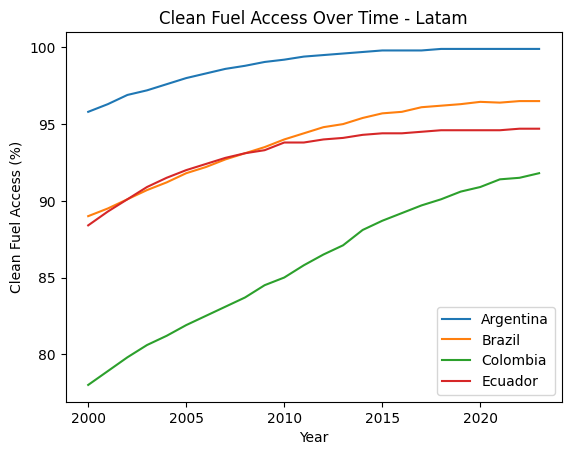

In [70]:
plt.figure()

for country in df_latam['country_name'].unique():
    subset = df_latam[df_latam['country_name'] == country]
    plt.plot(subset['year'], subset['value'])

plt.xlabel("Year")
plt.ylabel("Clean Fuel Access (%)")
plt.title("Clean Fuel Access Over Time - Latam")
plt.legend(df_latam['country_name'].unique())
plt.show()

#### urbal vs rural on brazil

In [71]:
df_brazil = con.execute("""
SELECT
    t.year,
    r.residence_type,
    f.value
FROM fact_clean_fuel_access f
JOIN dim_location l  ON f.location_id = l.location_id
JOIN dim_time t      ON f.time_id = t.time_id
JOIN dim_residence r ON f.residence_id = r.residence_id
WHERE l.country_name = 'Brazil'
ORDER BY t.year
""").df()

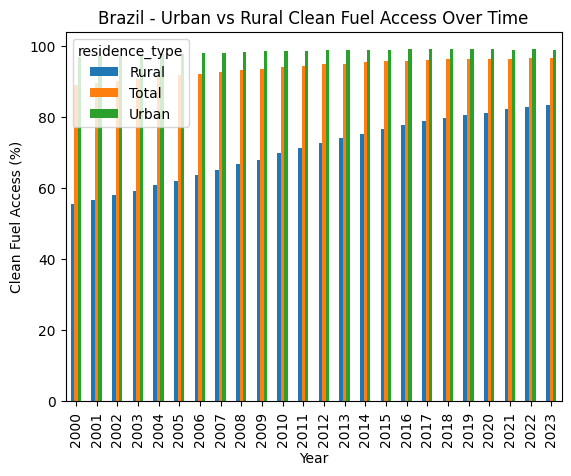

In [72]:
df_brazil_pivot = df_brazil.pivot(
    index='year',
    columns='residence_type',
    values='value'
)

df_brazil_pivot.plot(kind='bar')

plt.xlabel("Year")
plt.ylabel("Clean Fuel Access (%)")
plt.title("Brazil - Urban vs Rural Clean Fuel Access Over Time")
plt.show()

#### vzla

In [77]:
df_vzla = con.execute("""
SELECT
    t.year,
    r.residence_type,
    f.value
FROM fact_clean_fuel_access f
JOIN dim_location l  ON f.location_id = l.location_id
JOIN dim_time t      ON f.time_id = t.time_id
JOIN dim_residence r ON f.residence_id = r.residence_id
WHERE l.country_name = 'Venezuela (Bolivarian Republic of)'
ORDER BY t.year
""").df()

In [78]:
df_vzla.head()

,year,residence_type,value
0,2000,Rural,78.10
1,2000,Total,97.60
2,2000,Urban,99.50
3,2001,Rural,77.35
4,2001,Total,97.40


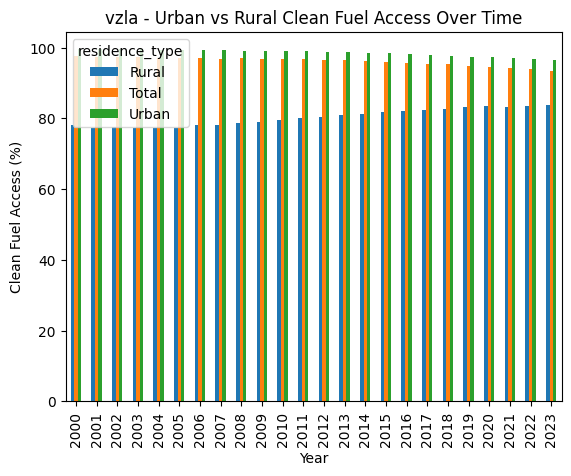

In [79]:
df_vzla_pivot = df_vzla.pivot(
    index='year',
    columns='residence_type',
    values='value'
)

df_vzla_pivot.plot(kind='bar')

plt.xlabel("Year")
plt.ylabel("Clean Fuel Access (%)")
plt.title("vzla - Urban vs Rural Clean Fuel Access Over Time")
plt.show()

#### africa

In [80]:
df_africa = con.execute("""
SELECT
    l.country_name,
    f.value
FROM fact_clean_fuel_access f
JOIN dim_location l  ON f.location_id = l.location_id
JOIN dim_residence r ON f.residence_id = r.residence_id
WHERE l.region_name = 'Africa'
  AND r.residence_type = 'Total'
  AND f.is_latest_year = TRUE
""").df()

In [81]:
import plotly.express as px

fig = px.choropleth(
    df_africa,
    locations="country_name",
    locationmode="country names",
    color="value",
    scope="africa",
    color_continuous_scale="Viridis",
    labels={"value": "Clean Fuel Access (%)"},
    title="Africa - Latest Clean Fuel Access (%)"
)

fig.show()